# Preprocessing

In [1]:
import pandas as pd
from path_config import PathConfig

paths = PathConfig()
# 1. Adım: Dosyayı oku
df = pd.read_excel(paths.dl_path, sheet_name='Series Formatted Data')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # Gereksiz boş kolonları çıkar

# 2. Adım: Kolon listeleri
expected_columns = [
    "Message", "Time", "Longitude", "Latitude", "Technology_Mode",
    "NR_UE_PCI_0", "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0",
    "NR_UE_Nbr_PCI_0", "NR_UE_Nbr_PCI_1", "NR_UE_Nbr_PCI_2", "NR_UE_Nbr_PCI_3", "NR_UE_Nbr_PCI_4",
    "NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRP_1", "NR_UE_Nbr_RSRP_2", "NR_UE_Nbr_RSRP_3", "NR_UE_Nbr_RSRP_4",
    "NR_UE_Nbr_RSRQ_0", "NR_UE_Nbr_RSRQ_1", "NR_UE_Nbr_RSRQ_2", "NR_UE_Nbr_RSRQ_3", "NR_UE_Nbr_RSRQ_4",
    "NR_UE_Timing_Advance", "NR_UE_Pathloss_DL_0", "NR_UE_Throughput_PDCP_DL", "App_Throughput_DL",
    "NR_UE_NACK_Rate_DL_0", "NR_UE_Ack_As_Nack_DL_0", "NR_UE_MCS_DL_0", "NR_UE_RB_Num_DL_0",
    "NR_UE_Modulation_Avg_DL_0", "NR_UE_RI_DL_0", "NR_UE_BLER_DL_0", "NR_UE_CCE_AggregationLev_0",
    "NR_UE_Power_Tx_PUSCH_0", "NR_UE_Power_Tx_PRACH_0", "NR_UE_NACK_Rate_UL_0",
    "NR_UE_RACH_Attempt", "NR_UE_RACH_OK", "NR_UE_RACH_Fail", "NR_UE_RACH_Procedure_Count",
    "NR_UE_RRCReEstAttempt", "NR_UE_RRCReEstFail", "NR_UE_RRCReEst_EndResult",
    "NR_UE_RRCConnectionAttempt", "NR_UE_RRCConnectionSetupOk", "NR_UE_RRCConnectionComplete",
    "NR_UE_RRCConnectionDrop", "NR_UE_RRCHOAttempt", "NR_UE_RRCHOOK",
    "NR_RRC_MsgType", "NAS_5GS_MM_MessageType", "NAS_5GS_SM_MessageType"
]

no_action_cols = [
    "Message", "Time", "Longitude", "Latitude", "Technology_Mode"
]

forward_fill_cols = [
    "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_Nbr_PCI_1", "NR_UE_Nbr_PCI_2", "NR_UE_Nbr_PCI_3", "NR_UE_Nbr_PCI_4",
    "NR_UE_MCS_DL_0", "NR_UE_RI_DL_0", "NR_UE_CCE_AggregationLev_0",
    "NR_UE_RACH_Attempt", "NR_UE_RACH_OK", "NR_UE_RACH_Fail", "NR_UE_RACH_Procedure_Count",
    "NR_UE_RRCReEstAttempt", "NR_UE_RRCReEstFail", "NR_UE_RRCReEst_EndResult",
    "NR_UE_RRCConnectionAttempt", "NR_UE_RRCConnectionSetupOk", "NR_UE_RRCConnectionComplete",
    "NR_UE_RRCConnectionDrop", "NR_UE_RRCHOAttempt", "NR_UE_RRCHOOK",
    "NR_RRC_MsgType", "NAS_5GS_MM_MessageType", "NAS_5GS_SM_MessageType"
]

linear_cols = [
    "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0",
    "NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRP_1", "NR_UE_Nbr_RSRP_2", "NR_UE_Nbr_RSRP_3", "NR_UE_Nbr_RSRP_4",
    "NR_UE_Nbr_RSRQ_0", "NR_UE_Nbr_RSRQ_1", "NR_UE_Nbr_RSRQ_2", "NR_UE_Nbr_RSRQ_3", "NR_UE_Nbr_RSRQ_4",
    "NR_UE_Timing_Advance", "NR_UE_Pathloss_DL_0",
    "NR_UE_NACK_Rate_DL_0", "NR_UE_Ack_As_Nack_DL_0", "NR_UE_BLER_DL_0",
    "NR_UE_RB_Num_DL_0", "NR_UE_Modulation_Avg_DL_0",
    "NR_UE_Power_Tx_PUSCH_0", "NR_UE_Power_Tx_PRACH_0",
    "NR_UE_NACK_Rate_UL_0"
]

spline_cols = [
    "NR_UE_Throughput_PDCP_DL", "App_Throughput_DL"
]

# 3. Adım: Eksik değerleri doldurma

# Linear Interpolation
for col in linear_cols:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

# Spline Interpolation
for col in spline_cols:
    if col in df.columns:
        df[col] = df[col].interpolate(method='spline', order=2, limit_direction='both')

# Forward Fill
for col in forward_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(method='ffill')

# 4. Adım: One-Hot Encoding yapılacak PCI kolonları
pci_cols = [
    'NR_UE_PCI_0', 'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_PCI_1', 'NR_UE_Nbr_PCI_2', 'NR_UE_Nbr_PCI_3', 'NR_UE_Nbr_PCI_4'
]

# PCI kolonları için One-Hot Encoding (NaN'ler 0 olacak)
df = pd.get_dummies(df, columns=pci_cols, dummy_na=False)

# 5. Adım: Satır ve Kolon Çıkarma

# Satırdan NaN çıkarılacak kolonlar
drop_row_cols = [
    'Longitude', 'Latitude', 'NR_UE_MCS_DL_0', 'NR_UE_RI_DL_0',
    'NR_UE_CCE_AggregationLev_0', 'NR_RRC_MsgType', 'NR_UE_RACH_Procedure_Count'
]
df = df.dropna(subset=drop_row_cols)

# Kolondan tamamen çıkarılacaklar
drop_column_cols = [
    'NR_UE_PCI_0', 'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_PCI_1', 'NR_UE_Nbr_PCI_2',
    'NR_UE_Nbr_PCI_3', 'NR_UE_Nbr_PCI_4', 'NR_UE_Modulation_Avg_DL_0',
    'NR_UE_RACH_Procedure_Count', 'NR_UE_RRCReEst_EndResult',
    'NAS_5GS_MM_MessageType', 'NAS_5GS_SM_MessageType'
]
df = df.drop(columns=drop_column_cols, errors='ignore')

# 6. Adım: NR_RRC_MsgType için de One-Hot Encoding yap
df = pd.get_dummies(df, columns=['NR_RRC_MsgType','NR_UE_MCS_DL_0', 'NR_UE_RI_DL_0', 'NR_UE_CCE_AggregationLev_0'], dummy_na=False)

# 7. Adım: Kalan eksik değerleri kontrol et
na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0]

print("Kalan Eksik (NaN) Değer Sayıları:")
print(na_counts)

# 8. Adım: Temizlenmiş dosyayı CSV olarak kaydet
df.to_csv(paths._processed_saha_olcum_dir / '5G_DL_DL_Filled.csv', index=False)

print("Temiz veri kaydedildi: 5G_DL_DL_Filled.csv ✅")


C:\Users\osman\AppData\Local\Temp\ipykernel_22996\2509771181.py:61: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[col] = df[col].interpolate(method='linear', limit_direction='both')
C:\Users\osman\AppData\Local\Temp\ipykernel_22996\2509771181.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill')


Kalan Eksik (NaN) Değer Sayıları:
Series([], dtype: int64)
Temiz veri kaydedildi: 5G_DL_DL_Filled.csv ✅


In [2]:
# Kalan NaN değerlerin kolon bazında sayımı
na_counts = df.isna().sum()

# Sadece en az 1 tane NaN olan kolonları göster
na_counts = na_counts[na_counts > 0]

print("Kalan Eksik (NaN) Değer Sayıları:")
print(na_counts)


Kalan Eksik (NaN) Değer Sayıları:
Series([], dtype: int64)


In [3]:
# Aynı olan (tamamen birebir aynı) satırları bulalım
duplicated_rows = df[df.duplicated(keep=False)]  # keep=False: tüm tekrarları işaretler

# Eğer varsa, kaç tane var yazdıralım
num_duplicates = duplicated_rows.shape[0]

print(f"Toplam {num_duplicates} tane birebir aynı (duplicate) satır bulundu.")

# Eğer varsa ilk birkaçını yazdır
if num_duplicates > 0:
    print("Örnek duplicate satırlar:")
    print(duplicated_rows.head())
else:
    print("Birebir aynı (duplicate) satır bulunamadı.")


Toplam 0 tane birebir aynı (duplicate) satır bulundu.
Birebir aynı (duplicate) satır bulunamadı.


Mevcut Kolonlar (37 adet):
['NR_UE_RACH_Attempt', 'NR_UE_RACH_OK', 'NR_UE_RACH_Fail', 'NR_UE_RRCReEstAttempt', 'NR_UE_RRCReEstFail', 'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnectionSetupOk', 'NR_UE_RRCConnectionComplete', 'NR_UE_RRCConnectionDrop', 'NR_UE_RRCHOAttempt', 'NR_UE_RRCHOOK', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRP_1', 'NR_UE_Nbr_RSRP_2', 'NR_UE_Nbr_RSRP_3', 'NR_UE_Nbr_RSRP_4', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRQ_1', 'NR_UE_Nbr_RSRQ_2', 'NR_UE_Nbr_RSRQ_3', 'NR_UE_Nbr_RSRQ_4', 'NR_UE_Timing_Advance', 'NR_UE_Pathloss_DL_0', 'NR_UE_NACK_Rate_DL_0', 'NR_UE_Ack_As_Nack_DL_0', 'NR_UE_BLER_DL_0', 'NR_UE_RB_Num_DL_0', 'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_Power_Tx_PRACH_0', 'NR_UE_NACK_Rate_UL_0', 'Longitude', 'Latitude', 'NR_UE_Throughput_PDCP_DL', 'App_Throughput_DL']


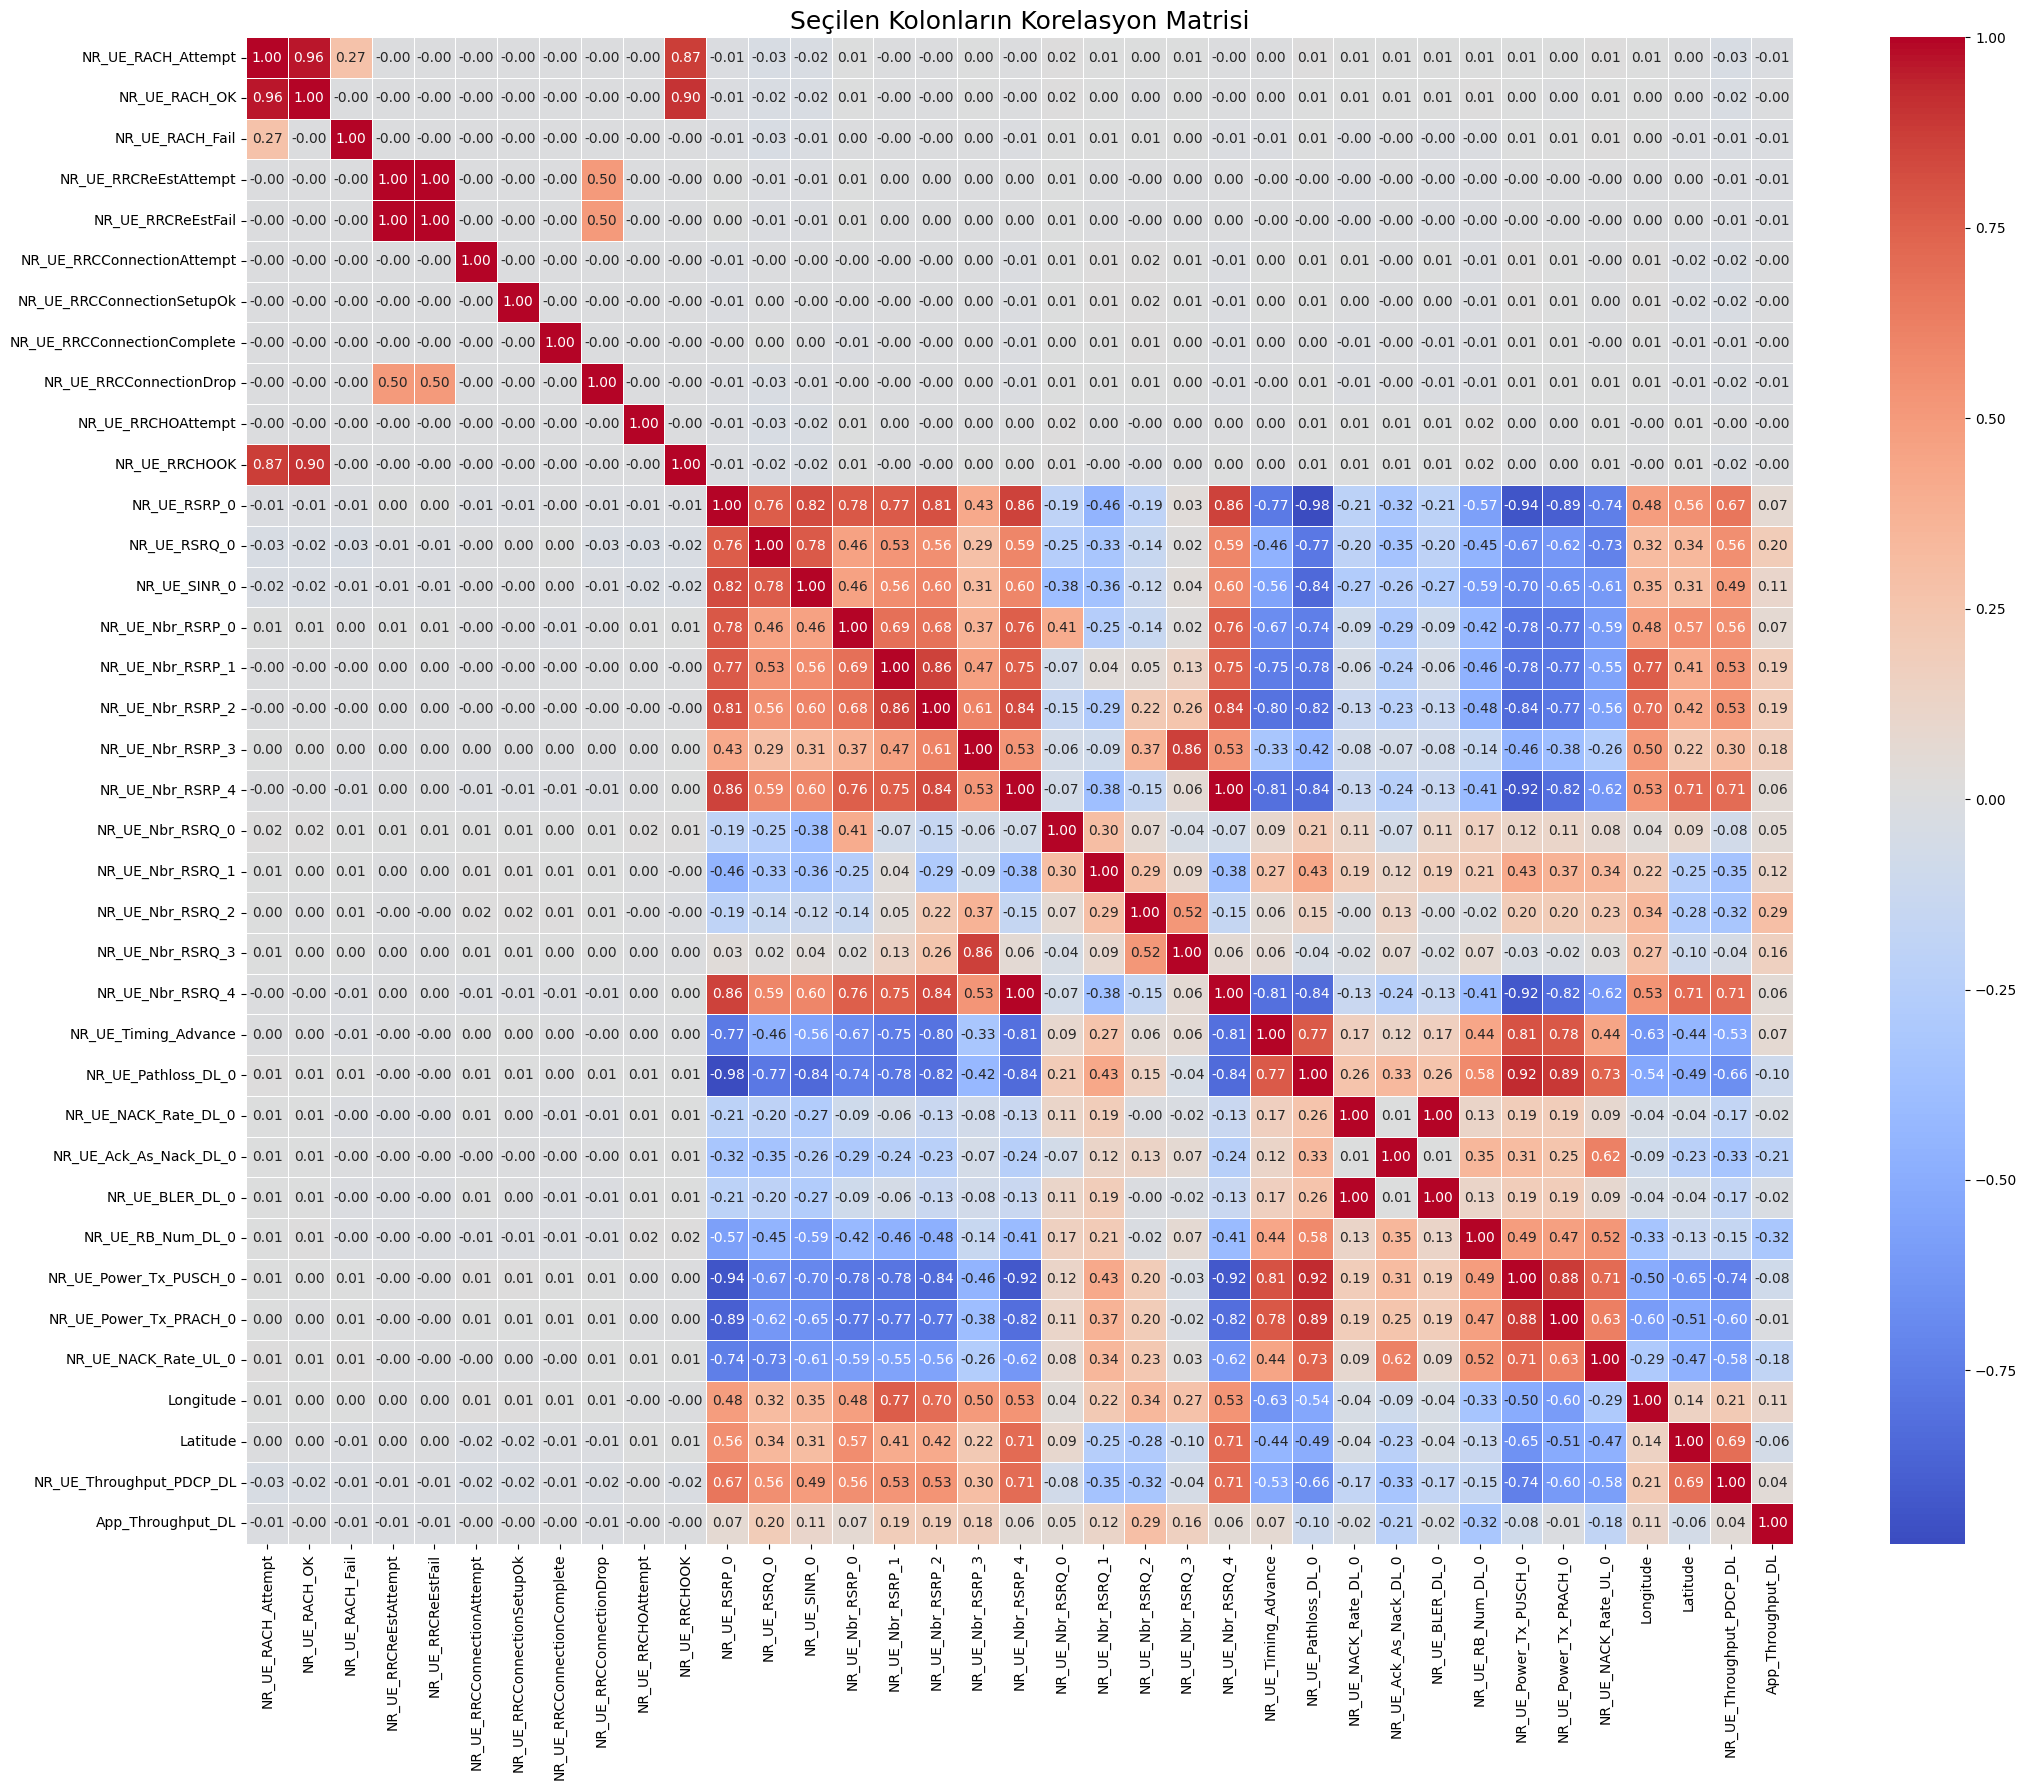

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CSV dosyasını oku
df = pd.read_csv(paths._processed_saha_olcum_dir / '5G_DL_DL_Filled.csv')

# 2. Kolon listeleri
forward_fill_cols = [
    "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_Nbr_PCI_1", "NR_UE_Nbr_PCI_2", "NR_UE_Nbr_PCI_3", "NR_UE_Nbr_PCI_4",
    "NR_UE_MCS_DL_0", "NR_UE_RI_DL_0", "NR_UE_CCE_AggregationLev_0",
    "NR_UE_RACH_Attempt", "NR_UE_RACH_OK", "NR_UE_RACH_Fail", "NR_UE_RACH_Procedure_Count",
    "NR_UE_RRCReEstAttempt", "NR_UE_RRCReEstFail", "NR_UE_RRCReEst_EndResult",
    "NR_UE_RRCConnectionAttempt", "NR_UE_RRCConnectionSetupOk", "NR_UE_RRCConnectionComplete",
    "NR_UE_RRCConnectionDrop", "NR_UE_RRCHOAttempt", "NR_UE_RRCHOOK",
    "NR_RRC_MsgType", "NAS_5GS_MM_MessageType", "NAS_5GS_SM_MessageType"
]

linear_cols = [
    "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0",
    "NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRP_1", "NR_UE_Nbr_RSRP_2", "NR_UE_Nbr_RSRP_3", "NR_UE_Nbr_RSRP_4",
    "NR_UE_Nbr_RSRQ_0", "NR_UE_Nbr_RSRQ_1", "NR_UE_Nbr_RSRQ_2", "NR_UE_Nbr_RSRQ_3", "NR_UE_Nbr_RSRQ_4",
    "NR_UE_Timing_Advance", "NR_UE_Pathloss_DL_0",
    "NR_UE_NACK_Rate_DL_0", "NR_UE_Ack_As_Nack_DL_0", "NR_UE_BLER_DL_0",
    "NR_UE_RB_Num_DL_0", "NR_UE_Modulation_Avg_DL_0",
    "NR_UE_Power_Tx_PUSCH_0", "NR_UE_Power_Tx_PRACH_0",
    "NR_UE_NACK_Rate_UL_0", "Longitude", "Latitude"
]

spline_cols = [
    "NR_UE_Throughput_PDCP_DL", "App_Throughput_DL"
]

# 3. Hepsini birleştir
all_cols = forward_fill_cols + linear_cols + spline_cols

# 4. Gerçekten dosyada bulunan kolonları bul
existing_cols = [col for col in all_cols if col in df.columns]

print(f"Mevcut Kolonlar ({len(existing_cols)} adet):")
print(existing_cols)

# 5. Sadece mevcut ve sayısal kolonları seç
df_selected = df[existing_cols].select_dtypes(include=[np.number])

# 6. Korelasyon matrisini hesapla
corr_matrix = df_selected.corr()

# 7. Korelasyon ısı haritası çiz
plt.figure(figsize=(22, 18))  # Büyük olsun daha net görünsün
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Seçilen Kolonların Korelasyon Matrisi', fontsize=18)
plt.xticks(rotation=90)  # Etiketleri dikey yap
plt.yticks(rotation=0)   # Etiketler yatay kalsın
plt.tight_layout()
plt.show()


# Model

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Veriyi oku
df = pd.read_csv(paths._processed_saha_olcum_dir / '5G_DL_DL_Filled.csv')

# 2. Özellikler ve hedefler
y = df[['Longitude', 'Latitude']]
X = df.drop(columns=[
    'Longitude', 'Latitude', 'Time', 'Message', 'Technology_Mode'
])

# 3. Eğitim ve test verilerine böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_long_list = []
rmse_lat_list = []
mae_long_list = []
mae_lat_list = []

deg_to_meter = 111320  # 1 derece ≈ 111320 metre

print("===== Cross Validation Sonuçları (Train) =====")

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # XGBoost modeli
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror'
    )
    multi_model = MultiOutputRegressor(model)
    multi_model.fit(X_tr, y_tr)

    # Validation tahmini
    y_pred_val = multi_model.predict(X_val)

    # Validation RMSE ve MAE
    rmse_long = np.sqrt(mean_squared_error(y_val['Longitude'], y_pred_val[:, 0]))
    mae_long = mean_absolute_error(y_val['Longitude'], y_pred_val[:, 0])

    rmse_lat = np.sqrt(mean_squared_error(y_val['Latitude'], y_pred_val[:, 1]))
    mae_lat = mean_absolute_error(y_val['Latitude'], y_pred_val[:, 1])

    # Kaydet
    rmse_long_list.append(rmse_long)
    mae_long_list.append(mae_long)
    rmse_lat_list.append(rmse_lat)
    mae_lat_list.append(mae_lat)

    # Fold sonuçları
    print(f"Fold {fold+1}:")
    print(f"  Longitude RMSE: {rmse_long:.6f} degrees ≈ {rmse_long * deg_to_meter:.2f} meters")
    print(f"  Longitude MAE : {mae_long:.6f} degrees ≈ {mae_long * deg_to_meter:.2f} meters")
    print(f"  Latitude RMSE: {rmse_lat:.6f} degrees ≈ {rmse_lat * deg_to_meter:.2f} meters")
    print(f"  Latitude MAE : {mae_lat:.6f} degrees ≈ {mae_lat * deg_to_meter:.2f} meters\n")

# 5. Cross Validation ortalamaları
print("===== Cross Validation Ortalamaları =====")
print(f"Longitude CV RMSE ortalama: {np.mean(rmse_long_list):.6f} degrees ≈ {np.mean(rmse_long_list) * deg_to_meter:.2f} meters")
print(f"Longitude CV MAE  ortalama: {np.mean(mae_long_list):.6f} degrees ≈ {np.mean(mae_long_list) * deg_to_meter:.2f} meters")
print(f"Latitude CV RMSE ortalama : {np.mean(rmse_lat_list):.6f} degrees ≈ {np.mean(rmse_lat_list) * deg_to_meter:.2f} meters")
print(f"Latitude CV MAE  ortalama : {np.mean(mae_lat_list):.6f} degrees ≈ {np.mean(mae_lat_list) * deg_to_meter:.2f} meters\n")

# 6. Tüm train set ile eğit ve test set üzerinde tahmin yap
final_model = MultiOutputRegressor(xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
))
final_model.fit(X_train, y_train)

y_pred_test = final_model.predict(X_test)

# 7. Test Set Performansı
rmse_long_test = np.sqrt(mean_squared_error(y_test['Longitude'], y_pred_test[:, 0]))
mae_long_test = mean_absolute_error(y_test['Longitude'], y_pred_test[:, 0])

rmse_lat_test = np.sqrt(mean_squared_error(y_test['Latitude'], y_pred_test[:, 1]))
mae_lat_test = mean_absolute_error(y_test['Latitude'], y_pred_test[:, 1])

print("===== Test Set Performansı =====")
print(f"Longitude Test RMSE: {rmse_long_test:.6f} degrees ≈ {rmse_long_test * deg_to_meter:.2f} meters")
print(f"Longitude Test MAE : {mae_long_test:.6f} degrees ≈ {mae_long_test * deg_to_meter:.2f} meters")
print(f"Latitude Test RMSE: {rmse_lat_test:.6f} degrees ≈ {rmse_lat_test * deg_to_meter:.2f} meters")
print(f"Latitude Test MAE : {mae_lat_test:.6f} degrees ≈ {mae_lat_test * deg_to_meter:.2f} meters")


===== Cross Validation Sonuçları (Train) =====
Fold 1:
  Longitude RMSE: 0.000078 degrees ≈ 8.64 meters
  Longitude MAE : 0.000051 degrees ≈ 5.71 meters
  Latitude RMSE: 0.000083 degrees ≈ 9.27 meters
  Latitude MAE : 0.000040 degrees ≈ 4.41 meters

Fold 2:
  Longitude RMSE: 0.000078 degrees ≈ 8.69 meters
  Longitude MAE : 0.000050 degrees ≈ 5.53 meters
  Latitude RMSE: 0.000058 degrees ≈ 6.43 meters
  Latitude MAE : 0.000040 degrees ≈ 4.46 meters

Fold 3:
  Longitude RMSE: 0.000081 degrees ≈ 9.03 meters
  Longitude MAE : 0.000050 degrees ≈ 5.59 meters
  Latitude RMSE: 0.000058 degrees ≈ 6.49 meters
  Latitude MAE : 0.000041 degrees ≈ 4.52 meters

Fold 4:
  Longitude RMSE: 0.000079 degrees ≈ 8.75 meters
  Longitude MAE : 0.000051 degrees ≈ 5.69 meters
  Latitude RMSE: 0.000056 degrees ≈ 6.24 meters
  Latitude MAE : 0.000040 degrees ≈ 4.43 meters

Fold 5:
  Longitude RMSE: 0.000082 degrees ≈ 9.16 meters
  Longitude MAE : 0.000050 degrees ≈ 5.58 meters
  Latitude RMSE: 0.000057 degrees ≈

# time series split

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Veriyi oku
df = pd.read_csv(paths._processed_saha_olcum_dir / '5G_DL_DL_Filled.csv')

# 2. Özellikler ve hedefler
y = df[['Longitude', 'Latitude']]
X = df.drop(columns=[
    'Longitude', 'Latitude', 'Time', 'Message', 'Technology_Mode'
])

# 3. Eğitim ve test verilerine zaman sırasına göre böl (shuffle yapmadan)
n_samples = len(X)
split_idx = int(n_samples * 0.8)  # %80 eğitim, %20 test

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Cross Validation (Sadece train verisinde)
kf = KFold(n_splits=5, shuffle=False)  # Shuffle kapalı, zaman sırasını koruyoruz

rmse_long_list = []
rmse_lat_list = []
mae_long_list = []
mae_lat_list = []

deg_to_meter = 111320  # 1 derece ≈ 111320 metre

print("===== Cross Validation Sonuçları (Train) =====")

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # XGBoost modeli
    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        objective='reg:squarederror'
    )
    multi_model = MultiOutputRegressor(model)
    multi_model.fit(X_tr, y_tr)

    # Validation tahmini
    y_pred_val = multi_model.predict(X_val)

    # Validation RMSE ve MAE
    rmse_long = np.sqrt(mean_squared_error(y_val['Longitude'], y_pred_val[:, 0]))
    mae_long = mean_absolute_error(y_val['Longitude'], y_pred_val[:, 0])

    rmse_lat = np.sqrt(mean_squared_error(y_val['Latitude'], y_pred_val[:, 1]))
    mae_lat = mean_absolute_error(y_val['Latitude'], y_pred_val[:, 1])

    # Kaydet
    rmse_long_list.append(rmse_long)
    mae_long_list.append(mae_long)
    rmse_lat_list.append(rmse_lat)
    mae_lat_list.append(mae_lat)

    # Fold sonuçları
    print(f"Fold {fold+1}:")
    print(f"  Longitude RMSE: {rmse_long:.6f} degrees ≈ {rmse_long * deg_to_meter:.2f} meters")
    print(f"  Longitude MAE : {mae_long:.6f} degrees ≈ {mae_long * deg_to_meter:.2f} meters")
    print(f"  Latitude RMSE: {rmse_lat:.6f} degrees ≈ {rmse_lat * deg_to_meter:.2f} meters")
    print(f"  Latitude MAE : {mae_lat:.6f} degrees ≈ {mae_lat * deg_to_meter:.2f} meters\n")

# 5. Cross Validation ortalamaları
print("===== Cross Validation Ortalamaları =====")
print(f"Longitude CV RMSE ortalama: {np.mean(rmse_long_list):.6f} degrees ≈ {np.mean(rmse_long_list) * deg_to_meter:.2f} meters")
print(f"Longitude CV MAE  ortalama: {np.mean(mae_long_list):.6f} degrees ≈ {np.mean(mae_long_list) * deg_to_meter:.2f} meters")
print(f"Latitude CV RMSE ortalama : {np.mean(rmse_lat_list):.6f} degrees ≈ {np.mean(rmse_lat_list) * deg_to_meter:.2f} meters")
print(f"Latitude CV MAE  ortalama : {np.mean(mae_lat_list):.6f} degrees ≈ {np.mean(mae_lat_list) * deg_to_meter:.2f} meters\n")

# 6. Tüm train set ile eğit ve test set üzerinde tahmin yap
final_model = MultiOutputRegressor(xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    objective='reg:squarederror'
))
final_model.fit(X_train, y_train)

y_pred_test = final_model.predict(X_test)

# 7. Test Set Performansı
rmse_long_test = np.sqrt(mean_squared_error(y_test['Longitude'], y_pred_test[:, 0]))
mae_long_test = mean_absolute_error(y_test['Longitude'], y_pred_test[:, 0])

rmse_lat_test = np.sqrt(mean_squared_error(y_test['Latitude'], y_pred_test[:, 1]))
mae_lat_test = mean_absolute_error(y_test['Latitude'], y_pred_test[:, 1])

print("===== Test Set Performansı =====")
print(f"Longitude Test RMSE: {rmse_long_test:.6f} degrees ≈ {rmse_long_test * deg_to_meter:.2f} meters")
print(f"Longitude Test MAE : {mae_long_test:.6f} degrees ≈ {mae_long_test * deg_to_meter:.2f} meters")
print(f"Latitude Test RMSE: {rmse_lat_test:.6f} degrees ≈ {rmse_lat_test * deg_to_meter:.2f} meters")
print(f"Latitude Test MAE : {mae_lat_test:.6f} degrees ≈ {mae_lat_test * deg_to_meter:.2f} meters")


===== Cross Validation Sonuçları (Train) =====
Fold 1:
  Longitude RMSE: 0.002314 degrees ≈ 257.61 meters
  Longitude MAE : 0.002073 degrees ≈ 230.81 meters
  Latitude RMSE: 0.001297 degrees ≈ 144.36 meters
  Latitude MAE : 0.001090 degrees ≈ 121.30 meters

Fold 2:
  Longitude RMSE: 0.001235 degrees ≈ 137.43 meters
  Longitude MAE : 0.001045 degrees ≈ 116.38 meters
  Latitude RMSE: 0.000848 degrees ≈ 94.42 meters
  Latitude MAE : 0.000703 degrees ≈ 78.26 meters

Fold 3:
  Longitude RMSE: 0.002041 degrees ≈ 227.23 meters
  Longitude MAE : 0.001663 degrees ≈ 185.16 meters
  Latitude RMSE: 0.001278 degrees ≈ 142.26 meters
  Latitude MAE : 0.001074 degrees ≈ 119.59 meters

Fold 4:
  Longitude RMSE: 0.002039 degrees ≈ 226.96 meters
  Longitude MAE : 0.001504 degrees ≈ 167.41 meters
  Latitude RMSE: 0.000785 degrees ≈ 87.37 meters
  Latitude MAE : 0.000605 degrees ≈ 67.34 meters

Fold 5:
  Longitude RMSE: 0.005836 degrees ≈ 649.69 meters
  Longitude MAE : 0.005211 degrees ≈ 580.13 meters
  L

Feature Importances (İlk 10 Özellik):
NR_UE_Nbr_PCI_2_23.0: 0.505138
NR_UE_Nbr_PCI_2_76.0: 0.103097
NR_UE_Nbr_PCI_1_76.0: 0.084974
NR_UE_Nbr_PCI_2_40.0: 0.075368
NR_UE_PCI_0_76.0: 0.040284
NR_UE_Power_Tx_PRACH_0: 0.029699
NR_UE_PCI_0_30.0: 0.023341
NR_UE_PCI_0_48.0: 0.022223
NR_UE_Nbr_RSRQ_2: 0.021955
NR_UE_Nbr_RSRQ_1: 0.019112


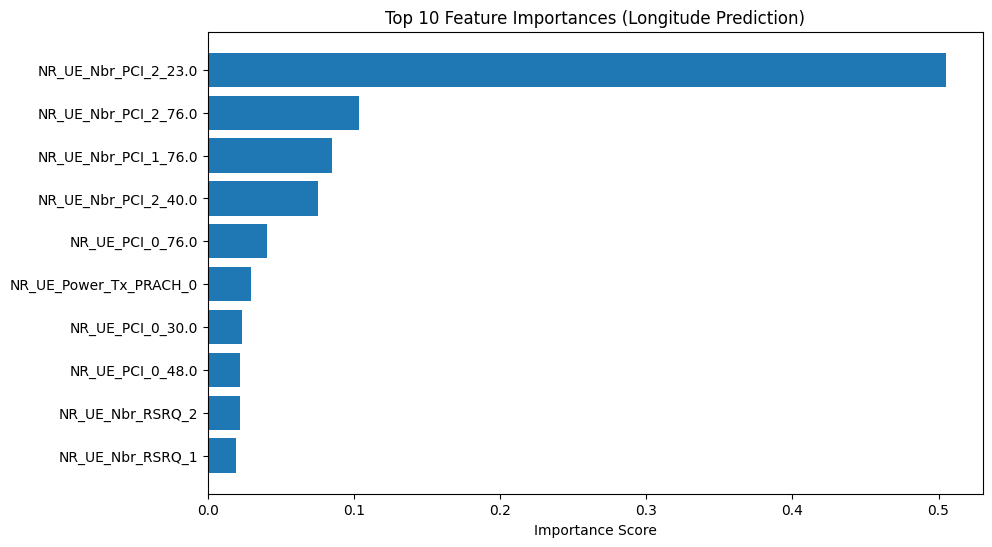

In [7]:
import matplotlib.pyplot as plt

# MultiOutputRegressor kullandığımız için iç modellerden birini seçiyoruz (örneğin Longitude için)
base_model = multi_model.estimators_[0]  # İlk modeli (Longitude modeli) alıyoruz

# Feature importance değerlerini al
importances = base_model.feature_importances_

# Feature isimleri
feature_names = X.columns

# Feature'ları importance değerine göre sırala (büyükten küçüğe)
feature_importance_list = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

# İlk 10 feature'ı al
top_10_features = feature_importance_list[:10]

# Yazdır
print("Feature Importances (İlk 10 Özellik):")
for feature, importance in top_10_features:
    print(f"{feature}: {importance:.6f}")

# Grafik için hazırlık
features, scores = zip(*top_10_features)

# Grafik çiz
plt.figure(figsize=(10, 6))
plt.barh(features, scores)
plt.gca().invert_yaxis()  # En önemli olanı üste getir
plt.title("Top 10 Feature Importances (Longitude Prediction)")
plt.xlabel("Importance Score")
plt.show()


# Group by preprocessing for seconds

In [8]:
import pandas as pd
import numpy as np

# 1. Veriyi oku
df = pd.read_csv(paths._processed_saha_olcum_dir / '5G_DL_DL_Filled.csv')

# 2. Time kolonunu datetime yap ve saniyeye yuvarla
df['Time'] = pd.to_datetime(df['Time'])
df['Time'] = df['Time'].dt.floor('S')

# 3. Kolon kategorilerini belirle
time_col = ['Time']
non_numeric_cols = ['Message', 'Technology_Mode']

continuous_cols = [
    'Longitude', 'Latitude',
    'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
    'NR_UE_Timing_Advance', 'NR_UE_Pathloss_DL_0',
    'NR_UE_Throughput_PDCP_DL', 'App_Throughput_DL',
    'NR_UE_NACK_Rate_DL_0', 'NR_UE_Ack_As_Nack_DL_0',
    'NR_UE_BLER_DL_0', 'NR_UE_RB_Num_DL_0',
    'NR_UE_Modulation_Avg_DL_0',  # <<< Burada olabilir yoksa çıkacak
    'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_Power_Tx_PRACH_0',
    'NR_UE_NACK_Rate_UL_0', 'NR_UE_RACH_Attempt', 'NR_UE_RACH_OK',
    'NR_UE_RACH_Fail', 'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnectionSetupOk',
    'NR_UE_RRCConnectionComplete', 'NR_UE_RRCConnectionDrop', 'NR_UE_RRCHOAttempt',
    'NR_UE_RRCHOOK',
    'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRP_1', 'NR_UE_Nbr_RSRP_2', 'NR_UE_Nbr_RSRP_3', 'NR_UE_Nbr_RSRP_4',
    'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRQ_1', 'NR_UE_Nbr_RSRQ_2', 'NR_UE_Nbr_RSRQ_3', 'NR_UE_Nbr_RSRQ_4'
]

categorical_last_cols = [
    'NR_UE_PCI_0',
    'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_PCI_1', 'NR_UE_Nbr_PCI_2', 'NR_UE_Nbr_PCI_3', 'NR_UE_Nbr_PCI_4',
    'NR_UE_MCS_DL_0', 'NR_UE_RI_DL_0', 'NR_UE_CCE_AggregationLev_0'
]

one_hot_cols = [col for col in df.columns if ('_' in col and col not in continuous_cols and col not in categorical_last_cols)]

# Şu anda df'de var olmayan kolonları çıkaralım
continuous_cols = [col for col in continuous_cols if col in df.columns]
categorical_last_cols = [col for col in categorical_last_cols if col in df.columns]
one_hot_cols = [col for col in one_hot_cols if col in df.columns]

# 4. GroupBy işlemleri
grouped = df.groupby('Time')

# 4.1 Continuous kolonlar için ortalama
df_continuous = grouped[continuous_cols].mean()

# 4.2 Kategorik kolonlar için sonuncu
df_categorical_last = grouped[categorical_last_cols + non_numeric_cols].last()

# 4.3 One-hot kolonlar için mod
def safe_mode(x):
    if x.mode().empty:
        return x.iloc[-1]  # Mod yoksa sonuncu
    else:
        return x.mode().iloc[0]

df_one_hot = grouped[one_hot_cols].agg(safe_mode)

# 5. Hepsini birleştir
df_final = pd.concat([df_continuous, df_one_hot, df_categorical_last], axis=1).reset_index()

print(f"Sonuç veri shape: {df_final.shape}")
print(df_final.head())


C:\Users\osman\AppData\Local\Temp\ipykernel_22996\3021969162.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['Time'] = df['Time'].dt.floor('S')


Sonuç veri shape: (1042, 139)
                 Time  Longitude   Latitude  NR_UE_RSRP_0  NR_UE_RSRQ_0  \
0 2025-03-14 12:14:56  29.028620  41.106760    -83.876316    -13.342105   
1 2025-03-14 12:14:57  29.028580  41.106730    -78.190424    -11.315789   
2 2025-03-14 12:14:58  29.028507  41.106677    -74.696560    -10.788975   
3 2025-03-14 12:14:59  29.028447  41.106627    -80.362653    -12.323853   
4 2025-03-14 12:15:00  29.028381  41.106571    -78.951912    -12.747475   

   NR_UE_SINR_0  NR_UE_Timing_Advance  NR_UE_Pathloss_DL_0  \
0      2.697368              3.990351           102.137255   
1      8.944152              3.939881            97.238698   
2     11.785953              3.841168            92.332779   
3      5.740095              3.729837            95.673504   
4      6.594053              3.622959            95.180122   

   NR_UE_Throughput_PDCP_DL  App_Throughput_DL  ...  NR_UE_RI_DL_0_Rank2  \
0              58242.369687       93836.455155  ...                Fal

In [9]:
# Son olarak CSV'ye kaydet
df_final.to_csv(paths._processed_saha_olcum_dir / '5G_DL_Grouped_Filled.csv', index=False)

print("Veri başarıyla '5G_DL_Grouped_Filled.csv' dosyasına kaydedildi.")


Veri başarıyla '5G_DL_Grouped_Filled.csv' dosyasına kaydedildi.


# Group by model

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Veriyi oku
df = pd.read_csv(paths._processed_saha_olcum_dir / '5G_DL_Grouped_Filled.csv')

# 2. Özellikler ve hedefler
y = df[['Longitude', 'Latitude']]
X = df.drop(columns=[
    'Longitude', 'Latitude', 'Time', 'Message', 'Technology_Mode'
])
X = X.apply(pd.to_numeric, errors='coerce')
# 3. Eğitim ve test verilerine zaman sırasına göre böl (shuffle yapmadan)
n_samples = len(X)
split_idx = int(n_samples * 0.8)  # %80 eğitim, %20 test

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Cross Validation (Sadece train verisinde)
kf = KFold(n_splits=5, shuffle=False)  # Shuffle kapalı, zaman sırasını koruyoruz

rmse_long_list = []
rmse_lat_list = []
mae_long_list = []
mae_lat_list = []

deg_to_meter = 111320  # 1 derece ≈ 111320 metre

print("===== Cross Validation Sonuçları (Train) =====")

for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # XGBoost modeli
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror'
    )
    multi_model = MultiOutputRegressor(model)
    multi_model.fit(X_tr, y_tr)

    # Validation tahmini
    y_pred_val = multi_model.predict(X_val)

    # Validation RMSE ve MAE
    rmse_long = np.sqrt(mean_squared_error(y_val['Longitude'], y_pred_val[:, 0]))
    mae_long = mean_absolute_error(y_val['Longitude'], y_pred_val[:, 0])

    rmse_lat = np.sqrt(mean_squared_error(y_val['Latitude'], y_pred_val[:, 1]))
    mae_lat = mean_absolute_error(y_val['Latitude'], y_pred_val[:, 1])

    # Kaydet
    rmse_long_list.append(rmse_long)
    mae_long_list.append(mae_long)
    rmse_lat_list.append(rmse_lat)
    mae_lat_list.append(mae_lat)

    # Fold sonuçları
    print(f"Fold {fold+1}:")
    print(f"  Longitude RMSE: {rmse_long:.6f} degrees ≈ {rmse_long * deg_to_meter:.2f} meters")
    print(f"  Longitude MAE : {mae_long:.6f} degrees ≈ {mae_long * deg_to_meter:.2f} meters")
    print(f"  Latitude RMSE: {rmse_lat:.6f} degrees ≈ {rmse_lat * deg_to_meter:.2f} meters")
    print(f"  Latitude MAE : {mae_lat:.6f} degrees ≈ {mae_lat * deg_to_meter:.2f} meters\n")

# 5. Cross Validation ortalamaları
print("===== Cross Validation Ortalamaları =====")
print(f"Longitude CV RMSE ortalama: {np.mean(rmse_long_list):.6f} degrees ≈ {np.mean(rmse_long_list) * deg_to_meter:.2f} meters")
print(f"Longitude CV MAE  ortalama: {np.mean(mae_long_list):.6f} degrees ≈ {np.mean(mae_long_list) * deg_to_meter:.2f} meters")
print(f"Latitude CV RMSE ortalama : {np.mean(rmse_lat_list):.6f} degrees ≈ {np.mean(rmse_lat_list) * deg_to_meter:.2f} meters")
print(f"Latitude CV MAE  ortalama : {np.mean(mae_lat_list):.6f} degrees ≈ {np.mean(mae_lat_list) * deg_to_meter:.2f} meters\n")

# 6. Tüm train set ile eğit ve test set üzerinde tahmin yap
final_model = MultiOutputRegressor(xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
))
final_model.fit(X_train, y_train)

y_pred_test = final_model.predict(X_test)

# 7. Test Set Performansı
rmse_long_test = np.sqrt(mean_squared_error(y_test['Longitude'], y_pred_test[:, 0]))
mae_long_test = mean_absolute_error(y_test['Longitude'], y_pred_test[:, 0])

rmse_lat_test = np.sqrt(mean_squared_error(y_test['Latitude'], y_pred_test[:, 1]))
mae_lat_test = mean_absolute_error(y_test['Latitude'], y_pred_test[:, 1])

print("===== Test Set Performansı =====")
print(f"Longitude Test RMSE: {rmse_long_test:.6f} degrees ≈ {rmse_long_test * deg_to_meter:.2f} meters")
print(f"Longitude Test MAE : {mae_long_test:.6f} degrees ≈ {mae_long_test * deg_to_meter:.2f} meters")
print(f"Latitude Test RMSE: {rmse_lat_test:.6f} degrees ≈ {rmse_lat_test * deg_to_meter:.2f} meters")
print(f"Latitude Test MAE : {mae_lat_test:.6f} degrees ≈ {mae_lat_test * deg_to_meter:.2f} meters")


===== Cross Validation Sonuçları (Train) =====
Fold 1:
  Longitude RMSE: 0.002277 degrees ≈ 253.49 meters
  Longitude MAE : 0.002008 degrees ≈ 223.53 meters
  Latitude RMSE: 0.001682 degrees ≈ 187.29 meters
  Latitude MAE : 0.001600 degrees ≈ 178.13 meters

Fold 2:
  Longitude RMSE: 0.002404 degrees ≈ 267.58 meters
  Longitude MAE : 0.001967 degrees ≈ 218.92 meters
  Latitude RMSE: 0.001288 degrees ≈ 143.42 meters
  Latitude MAE : 0.001106 degrees ≈ 123.16 meters

Fold 3:
  Longitude RMSE: 0.002438 degrees ≈ 271.36 meters
  Longitude MAE : 0.001830 degrees ≈ 203.73 meters
  Latitude RMSE: 0.001274 degrees ≈ 141.77 meters
  Latitude MAE : 0.001109 degrees ≈ 123.48 meters

Fold 4:
  Longitude RMSE: 0.002576 degrees ≈ 286.81 meters
  Longitude MAE : 0.002091 degrees ≈ 232.77 meters
  Latitude RMSE: 0.001029 degrees ≈ 114.53 meters
  Latitude MAE : 0.000739 degrees ≈ 82.22 meters

Fold 5:
  Longitude RMSE: 0.002998 degrees ≈ 333.73 meters
  Longitude MAE : 0.002732 degrees ≈ 304.11 meters


Feature Importances (İlk 10 Özellik):
NR_UE_Nbr_RSRP_1: 0.310988
NR_UE_Nbr_PCI_1_40.0: 0.194449
NR_UE_Nbr_RSRQ_2: 0.084837
NR_UE_PCI_0_68.0: 0.048212
NR_UE_Power_Tx_PRACH_0: 0.046937
NR_UE_SINR_0: 0.032218
NR_UE_Pathloss_DL_0: 0.025654
NR_UE_PCI_0_3.0: 0.024743
NR_UE_Nbr_RSRP_2: 0.024154
NR_UE_RI_DL_0_Rank2: 0.018543


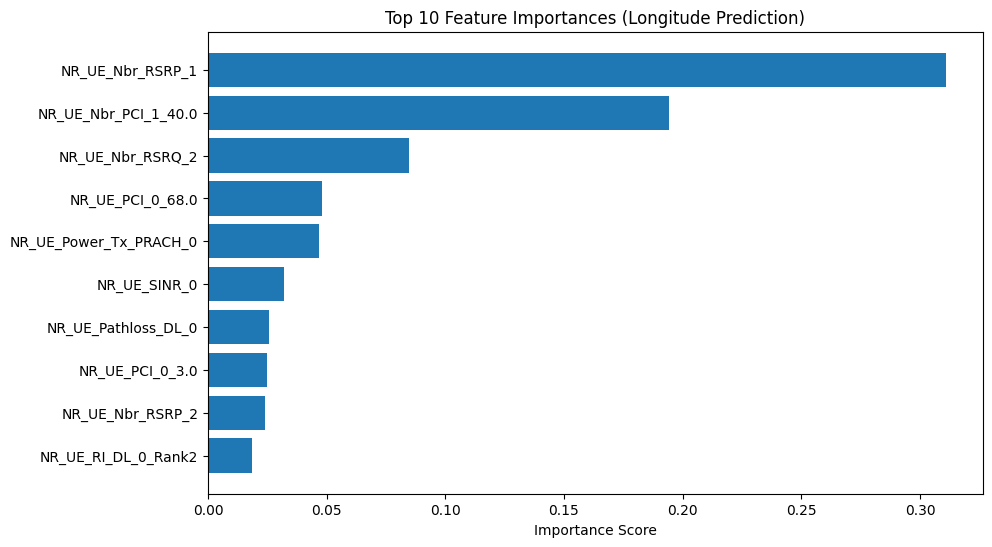

In [11]:
import matplotlib.pyplot as plt

# MultiOutputRegressor kullandığımız için iç modellerden birini seçiyoruz (örneğin Longitude için)
base_model = multi_model.estimators_[0]  # İlk modeli (Longitude modeli) alıyoruz

# Feature importance değerlerini al
importances = base_model.feature_importances_

# Feature isimleri
feature_names = X.columns

# Feature'ları importance değerine göre sırala (büyükten küçüğe)
feature_importance_list = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

# İlk 10 feature'ı al
top_10_features = feature_importance_list[:10]

# Yazdır
print("Feature Importances (İlk 10 Özellik):")
for feature, importance in top_10_features:
    print(f"{feature}: {importance:.6f}")

# Grafik için hazırlık
features, scores = zip(*top_10_features)

# Grafik çiz
plt.figure(figsize=(10, 6))
plt.barh(features, scores)
plt.gca().invert_yaxis()  # En önemli olanı üste getir
plt.title("Top 10 Feature Importances (Longitude Prediction)")
plt.xlabel("Importance Score")
plt.show()


Mevcut Kolonlar (37 adet):
['NR_UE_RACH_Attempt', 'NR_UE_RACH_OK', 'NR_UE_RACH_Fail', 'NR_UE_RRCReEstAttempt', 'NR_UE_RRCReEstFail', 'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnectionSetupOk', 'NR_UE_RRCConnectionComplete', 'NR_UE_RRCConnectionDrop', 'NR_UE_RRCHOAttempt', 'NR_UE_RRCHOOK', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRP_1', 'NR_UE_Nbr_RSRP_2', 'NR_UE_Nbr_RSRP_3', 'NR_UE_Nbr_RSRP_4', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRQ_1', 'NR_UE_Nbr_RSRQ_2', 'NR_UE_Nbr_RSRQ_3', 'NR_UE_Nbr_RSRQ_4', 'NR_UE_Timing_Advance', 'NR_UE_Pathloss_DL_0', 'NR_UE_NACK_Rate_DL_0', 'NR_UE_Ack_As_Nack_DL_0', 'NR_UE_BLER_DL_0', 'NR_UE_RB_Num_DL_0', 'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_Power_Tx_PRACH_0', 'NR_UE_NACK_Rate_UL_0', 'Longitude', 'Latitude', 'NR_UE_Throughput_PDCP_DL', 'App_Throughput_DL']


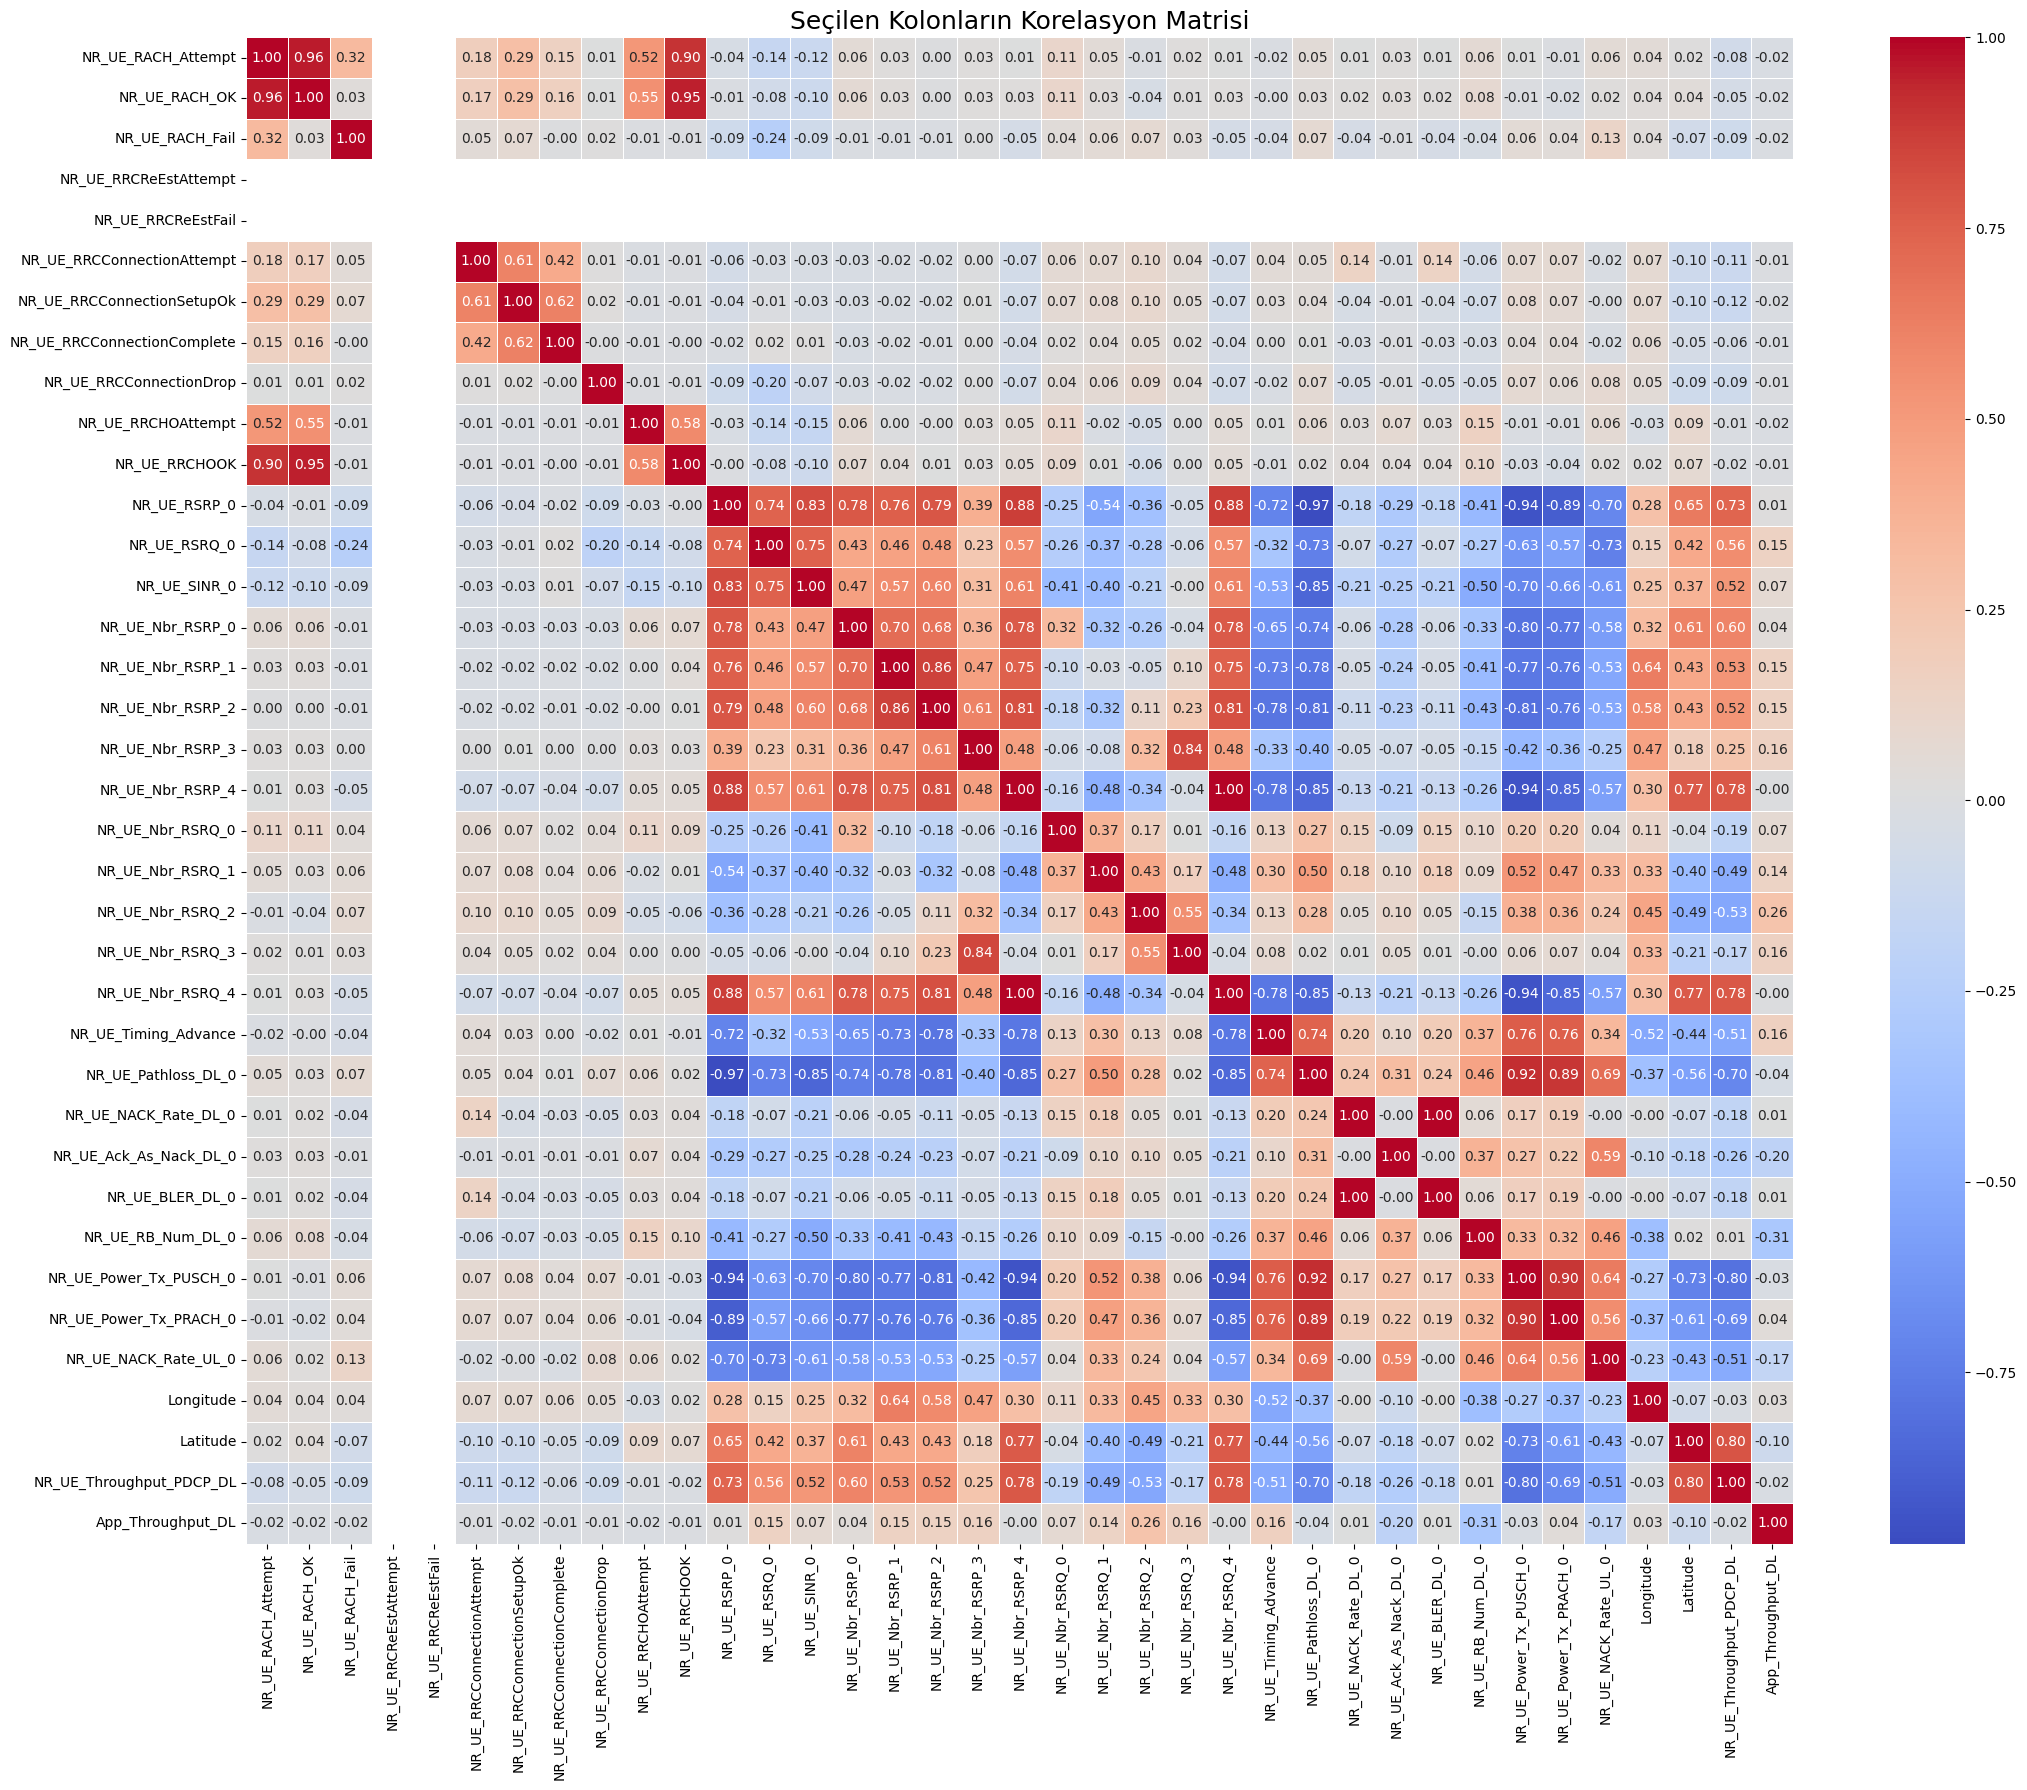

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CSV dosyasını oku
df = pd.read_csv(paths._processed_saha_olcum_dir / '5G_DL_Grouped_Filled.csv')

# 2. Kolon listeleri
forward_fill_cols = [
    "NR_UE_PCI_0", "NR_UE_Nbr_PCI_0", "NR_UE_Nbr_PCI_1", "NR_UE_Nbr_PCI_2", "NR_UE_Nbr_PCI_3", "NR_UE_Nbr_PCI_4",
    "NR_UE_MCS_DL_0", "NR_UE_RI_DL_0", "NR_UE_CCE_AggregationLev_0",
    "NR_UE_RACH_Attempt", "NR_UE_RACH_OK", "NR_UE_RACH_Fail", "NR_UE_RACH_Procedure_Count",
    "NR_UE_RRCReEstAttempt", "NR_UE_RRCReEstFail", "NR_UE_RRCReEst_EndResult",
    "NR_UE_RRCConnectionAttempt", "NR_UE_RRCConnectionSetupOk", "NR_UE_RRCConnectionComplete",
    "NR_UE_RRCConnectionDrop", "NR_UE_RRCHOAttempt", "NR_UE_RRCHOOK",
    "NR_RRC_MsgType", "NAS_5GS_MM_MessageType", "NAS_5GS_SM_MessageType"
]

linear_cols = [
    "NR_UE_RSRP_0", "NR_UE_RSRQ_0", "NR_UE_SINR_0",
    "NR_UE_Nbr_RSRP_0", "NR_UE_Nbr_RSRP_1", "NR_UE_Nbr_RSRP_2", "NR_UE_Nbr_RSRP_3", "NR_UE_Nbr_RSRP_4",
    "NR_UE_Nbr_RSRQ_0", "NR_UE_Nbr_RSRQ_1", "NR_UE_Nbr_RSRQ_2", "NR_UE_Nbr_RSRQ_3", "NR_UE_Nbr_RSRQ_4",
    "NR_UE_Timing_Advance", "NR_UE_Pathloss_DL_0",
    "NR_UE_NACK_Rate_DL_0", "NR_UE_Ack_As_Nack_DL_0", "NR_UE_BLER_DL_0",
    "NR_UE_RB_Num_DL_0", "NR_UE_Modulation_Avg_DL_0",
    "NR_UE_Power_Tx_PUSCH_0", "NR_UE_Power_Tx_PRACH_0",
    "NR_UE_NACK_Rate_UL_0", "Longitude", "Latitude"
]

spline_cols = [
    "NR_UE_Throughput_PDCP_DL", "App_Throughput_DL"
]

# 3. Hepsini birleştir
all_cols = forward_fill_cols + linear_cols + spline_cols

# 4. Gerçekten dosyada bulunan kolonları bul
existing_cols = [col for col in all_cols if col in df.columns]

print(f"Mevcut Kolonlar ({len(existing_cols)} adet):")
print(existing_cols)

# 5. Sadece mevcut ve sayısal kolonları seç
df_selected = df[existing_cols].select_dtypes(include=[np.number])

# 6. Korelasyon matrisini hesapla
corr_matrix = df_selected.corr()

# 7. Korelasyon ısı haritası çiz
plt.figure(figsize=(22, 18))  # Büyük olsun daha net görünsün
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Seçilen Kolonların Korelasyon Matrisi', fontsize=18)
plt.xticks(rotation=90)  # Etiketleri dikey yap
plt.yticks(rotation=0)   # Etiketler yatay kalsın
plt.tight_layout()
plt.show()
